In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [20]:
data = {
    'income':[12,13,14,6,5,4],
    'credit_score':[750,780,800,300,400,460],
    'Status':['YES','YES','YES','NO','NO','NO']
}
df = pd.DataFrame(data)
df

,income,credit_score,Status
0,12,750,YES
1,13,780,YES
2,14,800,YES
3,6,300,NO
4,5,400,NO
5,4,460,NO


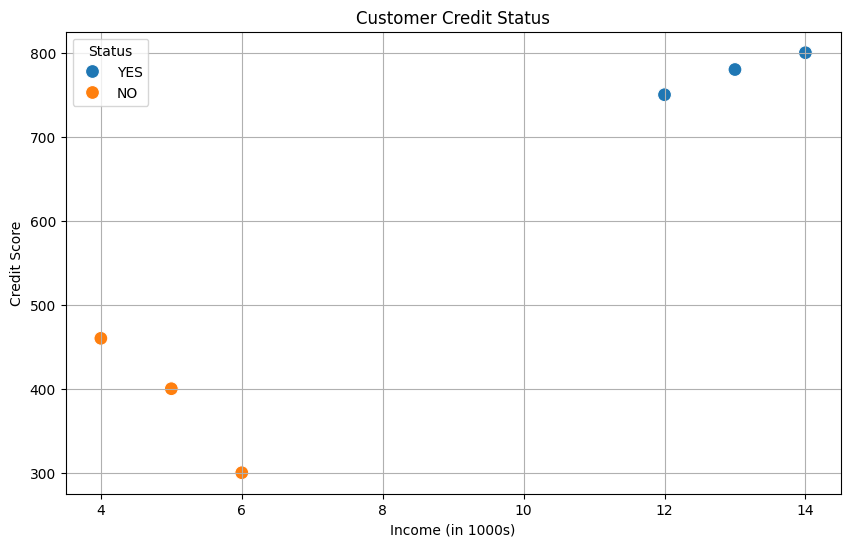

In [21]:
# lets plot the data
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='income', y='credit_score', hue='Status', s=100)
plt.title('Customer Credit Status')
plt.xlabel('Income (in 1000s)')
plt.ylabel('Credit Score')
plt.grid()
plt.show()

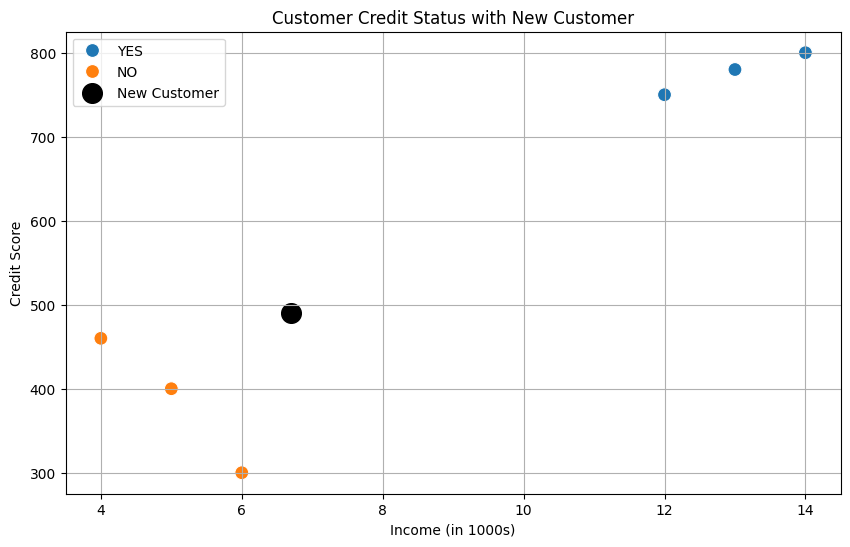

In [22]:
new_customer = [6.7,490]  # income=10k, credit_score=600
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='income', y='credit_score', hue='Status', s=100)
plt.scatter(new_customer[0], new_customer[1], color='black', s=200, label='New Customer')
plt.title('Customer Credit Status with New Customer')
plt.xlabel('Income (in 1000s)')
plt.ylabel('Credit Score')
plt.legend()
plt.grid()
plt.show()

In [23]:
# distance experiment
point_1 =[12,750]
point_2 =[12.2,900]
distance = np.sqrt((point_1[0]-point_2[0])**2 + (point_1[1]-point_2[1])**2)
distance

np.float64(150.00013333327408)

In [28]:
def euclidean_distance(df, points):
    distances = []
    for index, row in df.iterrows():
        dist = np.sqrt((row['income'] - points[0])**2 + (row['credit_score'] - points[1])**2)
        distances.append(dist)
    return distances
    

# new customer is the last row in df
new_customer = np.array([6.7,490])
df['Distance'] = euclidean_distance(df, new_customer)
df.sort_values(by='Distance')

# Top 4 closest points
df.nsmallest(4, 'Distance')['Status'].value_counts()

# Predicting the status based on majority vote
predicted_status = df.nsmallest(4, 'Distance')['Status'].mode()[0]
predicted_status

'NO'

In [29]:
# lets wrap all this in a function
def knn_predict(df, new_point, k=4):
    df['Distance'] = euclidean_distance(df, new_point)
    top_k = df.nsmallest(k, 'Distance')
    predicted_status = top_k['Status'].mode()[0]
    return predicted_status

knn_predict(df, new_customer, k=4)

'NO'

In [30]:
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# new_flower = [5.1,3.5,1.4,0.2]
# knn_predict(df, new_flower, k=5) # take this as a assignment
# hamming_distance
dna_1 = "AGCTTAGC"
dna_2 = "AGCTCGAC"
hamming_dist = sum(el1 != el2 for el1, el2 in zip(dna_1, dna_2))
hamming_dist
aa

3